In [5]:
!pip install pennylane --upgrade
!pip install qutip.qip
!pip install qutip
!sudo apt install cm-super dvipng texlive-latex-extra texlive-latex-recommended

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cm-super-minimal dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern
  fonts-noto-mono fonts-texgyre fonts-urw-base35 ghostscript
  libapache-pom-java libcommons-logging-java libcommons-parent-java
  libfontbox-java libfontenc1 libgs9 libgs9-common libidn12 libijs-0.35
  libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0 libsynctex2
  libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13 lmodern
  pfb2t1c2pfb poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  tex-common tex-gyre texlive-base texlive-binaries texlive-fonts-recommended
  texlive-latex-base texlive-pictures texlive-plain-generic tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf ghostscript-x
  libavalon-fram

In [6]:
import numpy as np
import pennylane as qml
from pennylane import numpy as np
from qutip import Qobj, tensor, identity, qeye, ket2dm,ptrace
import qutip as qt
from scipy.linalg import expm, sinm, cosm
from qutip_qip.operations import *

In [7]:
import matplotlib.pyplot as plt
font = {'weight' : 'bold',
        'size'   : 16}
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', **font)

# Analítica

(<Figure size 3000x700 with 1 Axes>, <Axes: >)

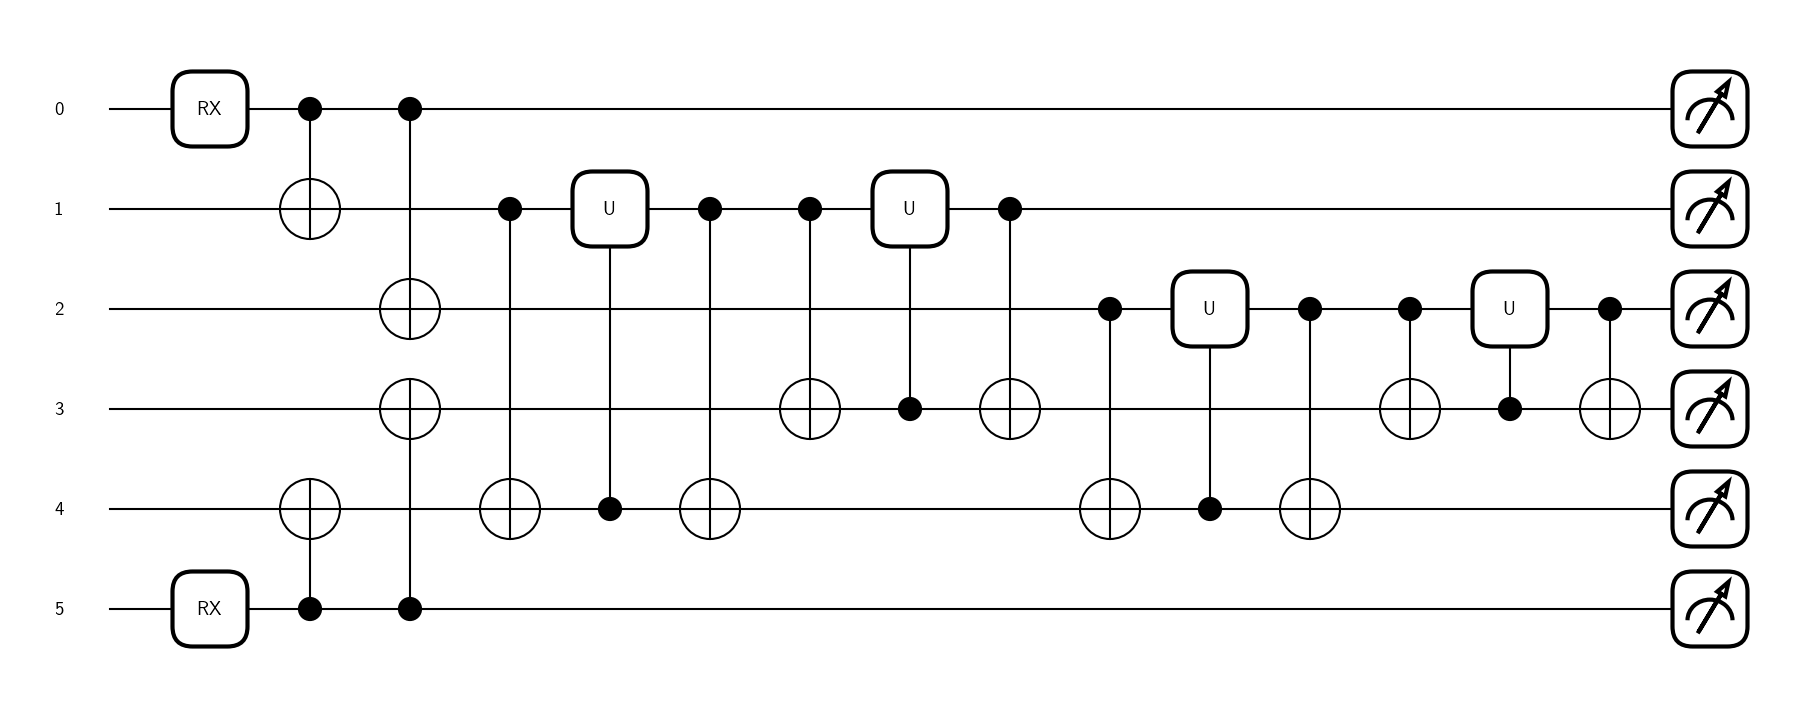

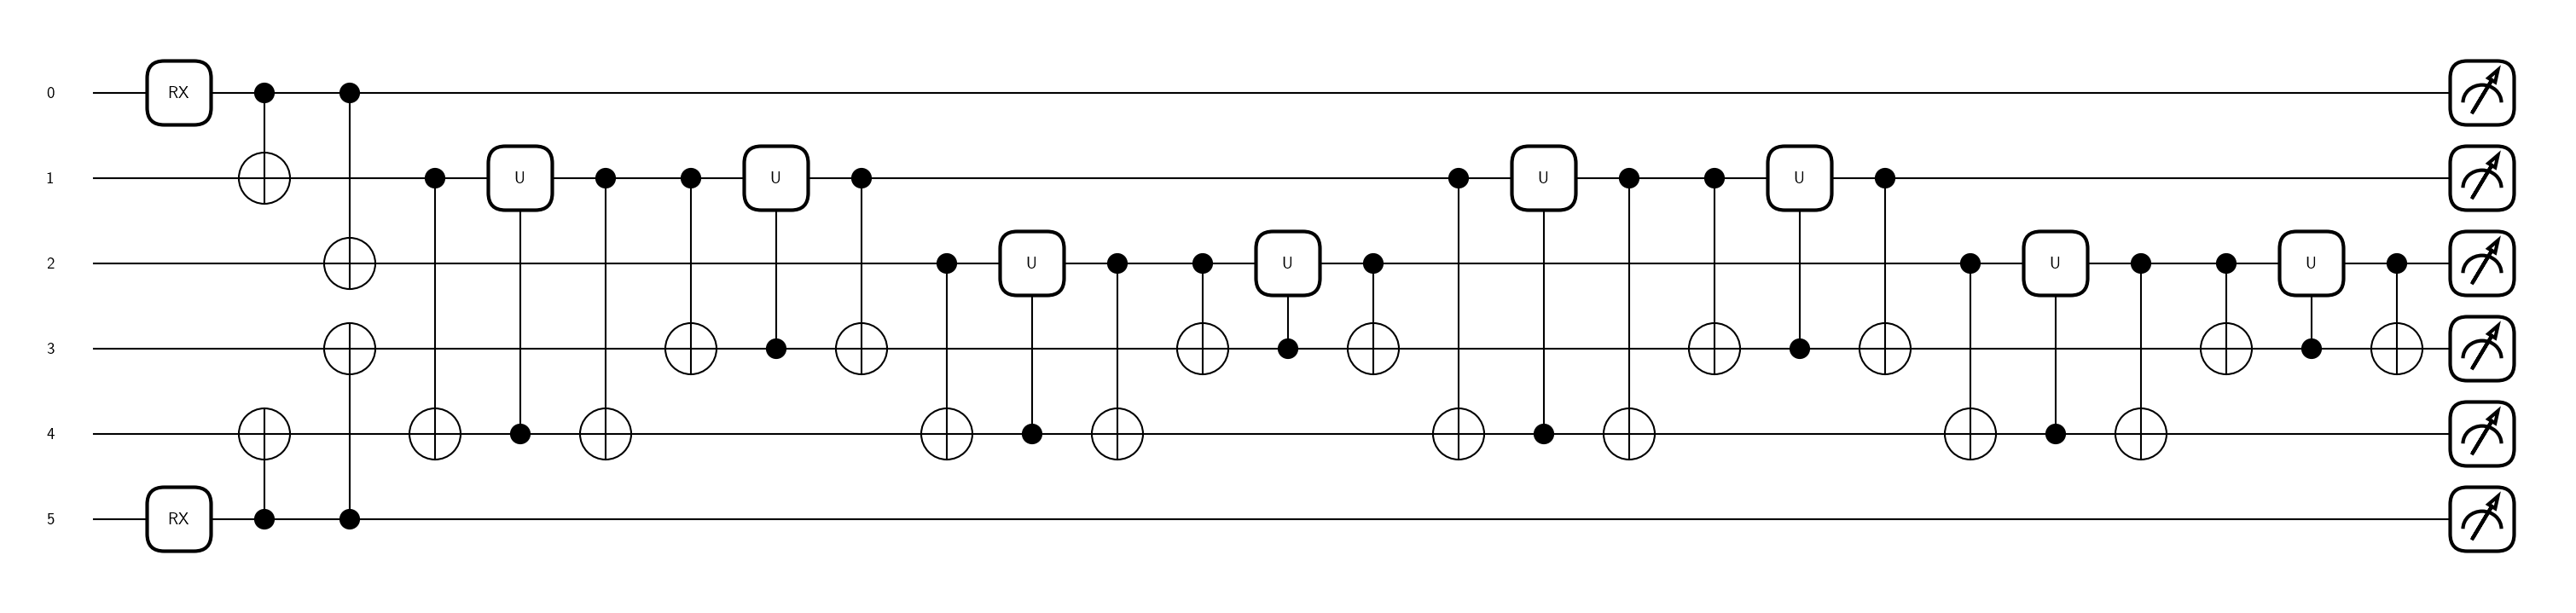

In [8]:
num_qubits = 6
dev1 = qml.device("default.qubit", wires=num_qubits)

def u_minus1(x):
    # Calculate the components
    term1 = 1 * np.sqrt(1 - x) * qeye(2)
    term2 = (1j * np.sqrt(x)) * qt.sigmay()
    u_minus = term1 - term2
    return np.array((u_minus).full())
def u_plus1(x):
    # Calculate the components
    term1 = 1 * np.sqrt(1 - x) * qeye(2)
    term2 = (1j * np.sqrt(x)) * qt.sigmay()
    u_minus = term1 + term2
    return np.array((u_minus).full())
#estado inicial e circuito inicial
@qml.qnode(dev1)
def phi_inicial(num_qubits,theta_A, theta_B,x=0.5):
    qml.RX(theta_A, wires=0)
    qml.RX(theta_B, wires=num_qubits-1)
    for i in range(1,int(num_qubits/2)):
      qml.CNOT(wires=[0, i])
      qml.CNOT(wires=[num_qubits-1,num_qubits-(i+1) ])
    for i in range(1,int(num_qubits/2)):
      for j in range(1,int(num_qubits/2)):
        qml.CNOT(wires=[i,num_qubits-(j+1)])
        qml.ControlledQubitUnitary(u_minus1(x), control_wires=[num_qubits-(j+1)], wires=[i])
        qml.CNOT(wires=[i,num_qubits-(j+1)])
    return qml.state()

@qml.qnode(dev1)
def phi_final(num_qubits,theta_A,theta_B,x=0.5):
    qml.RX(theta_A, wires=0)
    qml.RX(theta_B, wires=num_qubits-1)
    for i in range(1,int(num_qubits/2)):
      qml.CNOT(wires=[0, i])
      qml.CNOT(wires=[num_qubits-1,num_qubits-(i+1) ])
    for i in range(1,int(num_qubits/2)):
      for j in range(1,int(num_qubits/2)):
        qml.CNOT(wires=[i,num_qubits-(j+1)])
        qml.ControlledQubitUnitary(u_minus1(x), control_wires=[num_qubits-(j+1)], wires=[i])
        qml.CNOT(wires=[i,num_qubits-(j+1)])
    for i in range(1,int(num_qubits/2)):
      for j in range(1,int(num_qubits/2)):
        qml.CNOT(wires=[i,num_qubits-(j+1)])
        qml.ControlledQubitUnitary(u_plus1(x), control_wires=[num_qubits-(j+1)], wires=[i])
        qml.CNOT(wires=[i,num_qubits-(j+1)])
    return qml.state()

@qml.qnode(dev1)
def teste(initial_state,num_qubits,x=0.5):
    qml.QubitStateVector(initial_state, wires=range(int(num_qubits)))
    for i in range(1,int(num_qubits/2)):
      for j in range(1,int(num_qubits/2)):
        qml.CNOT(wires=[i,num_qubits-(j+1)])
        qml.ControlledQubitUnitary(u_plus1(x), control_wires=[num_qubits-(j+1)], wires=[i])
        qml.CNOT(wires=[i,num_qubits-(j+1)])
    return qml.state()



def hamiltoniana(eb,ea=1,num_qubits=4):
  #gerando a matriz identidade para gerar os circuitos
  resultfi=Qobj(qeye(2**(num_qubits-2)),dims=(cnot(num_qubits-2,0,1).dims))
  inteiro=int((num_qubits)/2)
  #gerando o hamiltoniano
  for i in range(1,num_qubits-1):
    result1=Qobj(1)
    result2=Qobj(1)
    for j in range(1,num_qubits-1):
      if i==j and i<inteiro:
        result1=tensor(result1,-ea*qt.sigmaz()/2)
        result2=tensor(result2,qeye(2))
      elif i==j and i>=inteiro:
        result2=tensor(result2,-eb*qt.sigmaz()/2)
        result1=tensor(result1,qeye(2))
      else:
        result1=tensor(result1,qeye(2))
        result2=tensor(result2,qeye(2))
    resultfi=resultfi+Qobj(result1+result2,dims=cnot(num_qubits-2,0,1).dims)
  return resultfi

def thetas_c(e,b,ea=1,ba=1):
 #parametro de correlação
  #parametros do sistema
  bb=b*ba
  eb=e*ea
  #hamiltoniana do sitema
  sz=np.array([[1, 0], [0, -1]])

  H_A=-0.5*ea*sz
  H_B=-0.5*eb*sz

  # Função partição
  Za = np.trace(expm(-ba * H_A))

  Zb = np.trace(expm(-bb * H_B))
  #operador densidade

  p_a=np.exp(-ba*ea/2)/Za
  p_b=np.exp(-bb*eb/2)/Zb
  #coeficiente

  a=1/(Za*Zb)**1.5

  pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

  pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

  x=((p_b-p_a)/(pp-pm)+1)*0.5
  #angulo para rotação x
  theta_a=2*np.arccos(np.sqrt(pp))
  theta_b=2*np.arccos(np.sqrt(pm))

  return theta_a,theta_b,x

qml.draw_mpl(phi_inicial)(num_qubits,1,1,0.5)
qml.draw_mpl(phi_final)(num_qubits,1,1,0.5)

AttributeError: module 'pennylane' has no attribute 'QubitStateVector'

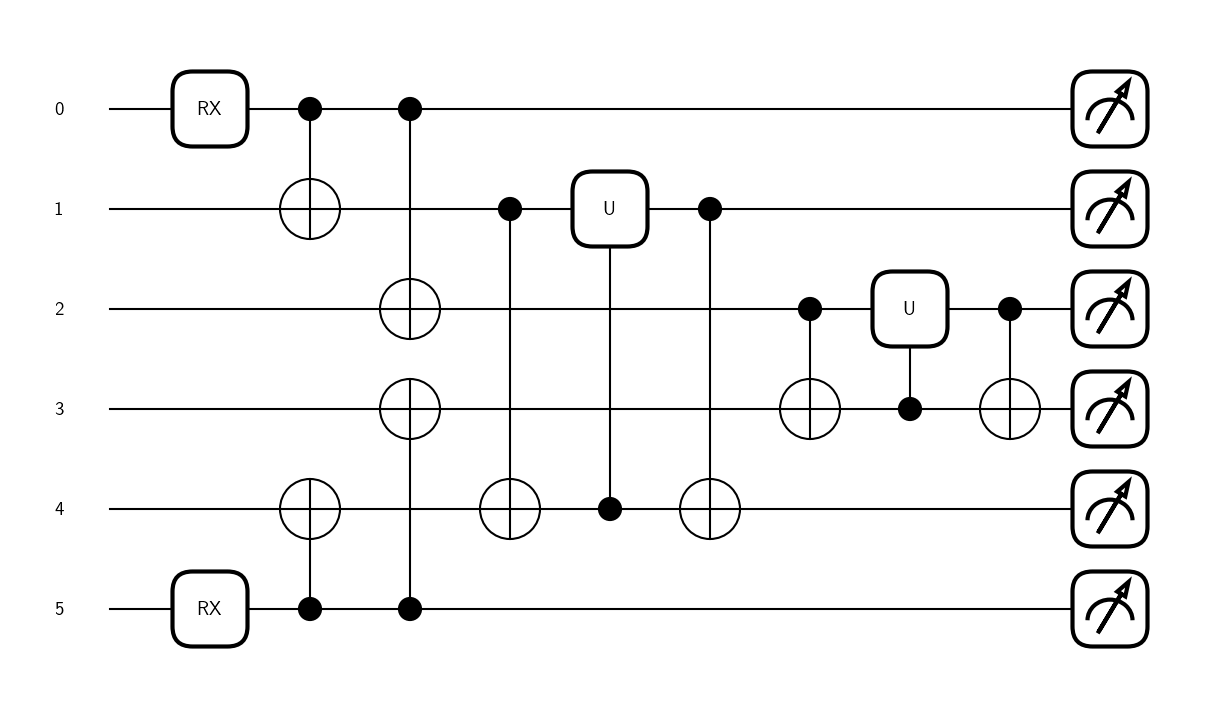

In [10]:
num_qubits = 6
dev1 = qml.device("default.qubit", wires=num_qubits)

@qml.qnode(dev1)
def phi_inicial2(num_qubits,theta_A, theta_B,x=0.5):
    qml.RX(theta_A, wires=0)
    qml.RX(theta_B, wires=num_qubits-1)
    for i in range(1,int(num_qubits/2)):
      qml.CNOT(wires=[0, i])
      qml.CNOT(wires=[num_qubits-1,num_qubits-(i+1) ])
    for i in range(1,int(num_qubits/2)):
      qml.CNOT(wires=[i,num_qubits-(i+1)])
      qml.ControlledQubitUnitary(u_minus1(x), control_wires=[num_qubits-(i+1)], wires=[i])
      qml.CNOT(wires=[i,num_qubits-(i+1)])
    return qml.state()


@qml.qnode(dev1)
def teste2(initial_state,num_qubits,x=0.5):
    qml.QubitStateVector(initial_state, wires=range(int(num_qubits)))
    for i in range(1,int(num_qubits/2)):
      qml.CNOT(wires=[i,num_qubits-(i+1)])
      qml.ControlledQubitUnitary(u_plus1(x), control_wires=[num_qubits-(i+1)], wires=[i])
      qml.CNOT(wires=[i,num_qubits-(i+1)])
    return qml.state()


qml.draw_mpl(phi_inicial2)(num_qubits,1,1,0.5)
qml.draw_mpl(teste2)(phi_inicial2(num_qubits,1,1,0.5),num_qubits,0.5)

In [11]:
#para pegar a dimensão
cnot_d=cnot(num_qubits,0,1)
#gerando o estado
eb=0
theta_a,theta_b,x=thetas_c(eb,2)
phiflag=phi_inicial(num_qubits,theta_a,theta_b,x)
phi0=Qobj(phiflag,dims=[cnot_d.dims[0],[1]])
phif=Qobj(teste(phiflag,num_qubits,0.6),dims=[cnot_d.dims[0],[1]])
i=num_qubits
trace_ind=np.linspace(1,i-2,i-2,dtype=int)

# calculando o trabalho novo
phi_0=phi0*phi0.dag()
phi_f=phif*phif.dag()
phi_0_trace=ptrace(phi_0,trace_ind)
rho0=phi_0_trace
phi_f_trace=ptrace(phi_f,trace_ind)
Hab=hamiltoniana(eb,1,num_qubits)
w1=((phi_f_trace-phi_0_trace)*Hab).tr()

#antigo trabalho
phiflag=phi_inicial2(num_qubits,theta_a,theta_b,x)
phi0=Qobj(phiflag,dims=[cnot_d.dims[0],[1]])
phif=Qobj(teste2(phiflag,num_qubits,0.6),dims=[cnot_d.dims[0],[1]])
phi_0_trace=ptrace(phi_0,trace_ind)
rho1=phi_0_trace
phi_f_trace=ptrace(phi_f,trace_ind)
w2=((phi_f_trace-phi_0_trace)*Hab).tr()

#trabalho 3
phiflag=phi_inicial2(num_qubits,theta_a,theta_b,x)
phi0=Qobj(phiflag,dims=[cnot_d.dims[0],[1]])
phif=Qobj(teste2(phiflag,num_qubits,0.6),dims=[cnot_d.dims[0],[1]])
phi_0_trace=ptrace(phi_0,trace_ind)

phi_f_trace=ptrace(phi_f,trace_ind)
w3=((phi_f_trace-phi_0_trace)*Hab).tr()



print(w1)
print(w2)
print(w3)

AttributeError: module 'pennylane' has no attribute 'QubitStateVector'

In [ ]:
print(np.count_nonzero(rho0.full()))
print(np.count_nonzero(rho1.full()))

# Artigo

## Primeiro exemplo do artigo

Estado de Bell: [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]
Estado final do sistema: [0.56575836-0.56575836j 0.32664074-0.32664074j 0.13529903+0.13529903j
 0.23434479+0.23434479j]


(<Figure size 600x300 with 1 Axes>, <Axes: >)

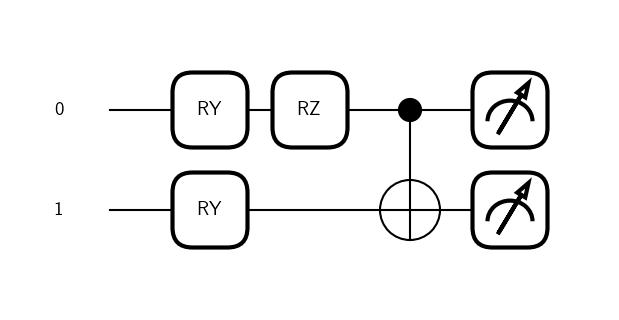

In [12]:
# @title Texto de título padrão
import pennylane as qml
from pennylane import numpy as np

# Número de qubits
num_qubits = 2

# Criar um dispositivo (simulador) quântico
dev = qml.device("default.qubit", wires=num_qubits)

# Definir o circuito quântico
@qml.qnode(dev)
def circuito(parametros):
    """
    Circuito quântico com rotações Ry e Rz e um CNOT.

    Args:
        parametros (list): Lista de parâmetros [alpha1, alpha2, alpha3].

    Returns:
        array: Estado quântico final do sistema.
    """

    # Parâmetros
    alpha1, alpha2, alpha3 = parametros

    # Rotações Ry
    qml.RY(alpha1, wires=0)
    qml.RY(alpha2, wires=1)

    # Rotação Rz
    qml.RZ(alpha3, wires=0)

    # Porta CNOT (Controlled-NOT)
    qml.CNOT(wires=[0, 1])

    return qml.state()


# Criar um dispositivo (simulador) quântico
dev = qml.device("default.qubit", wires=2)

# Definir o circuito quântico para criar o estado de Bell
@qml.qnode(dev)
def bell_state():
    qml.Hadamard(wires=0)  # Aplica a porta Hadamard no qubit 0
    qml.CNOT(wires=[0, 1])  # Aplica a porta CNOT com o qubit 0 como controle e o qubit 1 como alvo
    return qml.state()

# Executar o circuito e obter o estado final
state = bell_state()
print("Estado de Bell:", state)
# Exemplo de uso
parametros = [np.pi/4, np.pi/3, np.pi/2]  # Valores de exemplo para os parâmetros
resultado = circuito(parametros)

print("Estado final do sistema:", resultado)
qml.draw_mpl(circuito)(parametros)

Mapa positivo

In [13]:
rho_qu=Qobj(np.outer(state,np.conj(state)),dims=[[2,2],[2,2]])

Rbb=tensor(qeye(2),ptrace(rho_qu,1).tr()*qeye(2)-ptrace(rho_qu,1))
print(Rbb.eigenenergies())

[0.5 0.5 0.5 0.5]


In [14]:
import numpy as np
from qutip import Qobj, sigmax, sigmay, sigmaz , tensor, qeye,ptrace

def depolarizing_channel(rhoab, p):
    """
    Aplica o canal de despolarização a um estado quântico.

    Args:
        rho (Qobj): Matriz densidade representando o estado quântico.
        p (float): Probabilidade de erro (entre 0 e 1).

    Returns:
        Qobj: Matriz densidade do estado após a aplicação do canal.
    """
    rho=rhoab
    '''X = tensor(sigmax(),sigmax())
    Y = tensor(sigmay(),sigmay())
    Z = tensor(sigmaz(),sigmaz())'''

    X = sigmax()
    Y = sigmay()
    Z = sigmaz()
    return -rho*0.5 + (X * rho * X + Y * rho * Y + Z * rho * Z)*0.5

# Exemplo de uso

initial_state = bell_state()
rho = np.outer(initial_state, np.conj(initial_state))
print(rho)
rho_qu = Qobj(rho,dims=[[2,2],[2,2]])  # Estado inicial (|+⟩)
rho_qu = Qobj(ptrace(rho_qu,1),dims=[[2],[2]])
print(rho_qu)
p_error = 0.2  # Probabilidade de erro de 20%
final_state = depolarizing_channel(rho_qu, p_error)
#rho=ptrace(rho,1)
print("Estado final após o canal de despolarização:\n", final_state)
print('Reduction map:\n',rho_qu.tr()*qeye(2)-rho_qu)

[[0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]]
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0. ]
 [0.  0.5]]
Estado final após o canal de despolarização:
 Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0. ]
 [0.  0.5]]
Reduction map:
 Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0. ]
 [0.  0.5]]


<ipython-input-17-fbd3f6053f89>:67: ComplexWarning: Casting complex values to real discards the imaginary part
  params[j] -= learning_rate * gradient


Epoch 2, Loss: (-0.15946421259942242+0j)
Epoch 3, Loss: (-0.2617545662702655+0j)
Epoch 4, Loss: (-0.34358409835955184-3.469446951953614e-18j)
Epoch 5, Loss: (-0.40253284848944587+0j)
Epoch 6, Loss: (-0.44154403116024044+0j)
Epoch 7, Loss: (-0.4658252465012963+3.469446951953614e-18j)
Epoch 8, Loss: (-0.48033743146332486+1.734723475976807e-18j)
Epoch 9, Loss: (-0.4887949428090429+0j)
Epoch 10, Loss: (-0.49365021607973375+8.673617379884035e-19j)
Epoch 11, Loss: (-0.49641319198830686+0j)
Epoch 12, Loss: (-0.4979776204189815+0j)
Epoch 13, Loss: (-0.49886088611106005+0j)
Epoch 14, Loss: (-0.4993587646178841+0j)
Epoch 15, Loss: (-0.49963915180305946+0j)
Epoch 16, Loss: (-0.4997969743482692+0j)
[1.54350984 0.00618199 0.005422  ]


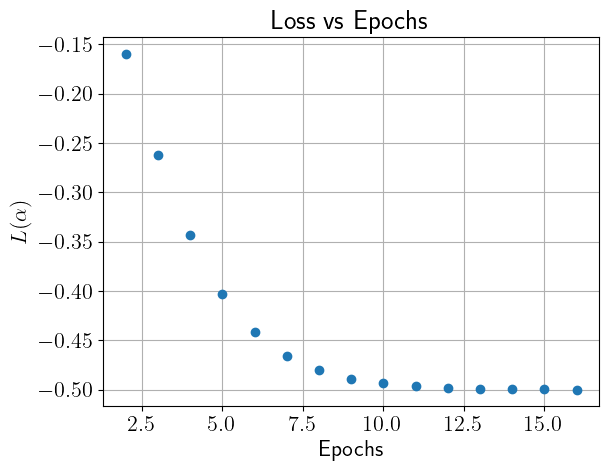

In [17]:
  #otimização
import numpy as np
import matplotlib.pyplot as plt

def loss2(state,rho):

    X = tensor(qeye(2),sigmax())
    Y = tensor(qeye(2),sigmay())
    Z = tensor(qeye(2),sigmaz())
    rho_red=-rho*0.5 + (X * rho * X + Y * rho * Y + Z * rho * Z)*0.5

    return state.dag()*rho_red*state
def loss(state,rho):

    psiab=state*state.dag()
    psib=ptrace(psiab,1)

    rhoab=rho
    rhob=ptrace(rho,1)

    return (psib*rhob).tr()-(rhoab*psiab).tr()

def loss_function(params):
    """
    Função de perda a ser minimizada.
    Substitua por sua própria função de perda.
    """
    #rho_ab
    initial_state = bell_state()
    rho = np.outer(initial_state, np.conj(initial_state))
    #psi_ab
    parametros = params # Valores de exemplo para os parâmetros
    state = circuito(parametros)
    #função
    rho_qu = Qobj(rho,dims=[[2,2],[2,2]])  # Estado inicial
    state_qu = Qobj(state,dims=[[2,2],[1]])

    return loss2(state_qu,rho_qu)

def parameter_shift_gradient(params, j):
    """
    Calcula o gradiente da função de perda em relação ao parâmetro j
    usando a regra parameter-shift.
    """
    shifted_params_plus = params.copy()
    shifted_params_plus[j] += np.pi / 2

    shifted_params_minus = params.copy()
    shifted_params_minus[j] -= np.pi / 2

    gradient = 0.5 * (loss_function(shifted_params_plus) - loss_function(shifted_params_minus))
    return gradient

def stochastic_gradient_descent(params, learning_rate, num_epochs,epsilon):
    """
    Executa o algoritmo SGD usando a regra parameter-shift para calcular gradientes.
    """
    epoch=0
    loss=0
    loss_vec=[]
    epochs_vec=[]

    while ( epoch<num_epochs):#np.real(loss)>(-epsilon) and
      epoch+=1
      for j in range(len(params)):
          gradient = parameter_shift_gradient(params, j)
          params[j] -= learning_rate * gradient

      # Avalie a função de perda após cada época, se desejar
      loss = loss_function(params)
      loss_vec.append(np.real(loss))
      epochs_vec.append(epoch+1)
      print(f"Epoch {epoch+1}, Loss: {loss}")

    return params,loss_vec,epochs_vec

# Exemplo de uso
params = np.random.rand(3)  # Inicialize os parâmetros aleatoriamente
learning_rate = 0.5
num_epochs = 15

optimized_params,vec1,vec2 = stochastic_gradient_descent(params, learning_rate,num_epochs,0.1)
print(optimized_params)
plt.plot(vec2,vec1,'o')
plt.xlabel('Epochs')
plt.ylabel('$L(\\alpha)$')
plt.grid(True)
plt.title('Loss vs Epochs')
plt.show()

In [18]:
import pennylane as qml
from pennylane import numpy as np

# Número de qubits
num_qubits = 2

# Criar um dispositivo (simulador) quântico
dev = qml.device("default.qubit", wires=num_qubits)

# Definir o circuito quântico
@qml.qnode(dev)
def circuito2(parametros,initial_state):
    """
    Circuito quântico com rotações Ry e Rz e um CNOT.

    Args:
        parametros (list): Lista de parâmetros [alpha1, alpha2, alpha3].

    Returns:
        array: Estado quântico final do sistema.
    """
    # Estado inicial
    qml.QubitStateVector(initial_state, wires=range(int(num_qubits)))
    # Parâmetros
    alpha1, alpha2, alpha3 = parametros

    # Rotações Ry
    qml.RY(alpha1, wires=0)
    qml.RY(alpha2, wires=1)

    # Rotação Rz
    qml.RZ(alpha3, wires=0)

    # Porta CNOT (Controlled-NOT)
    qml.CNOT(wires=[0, 1])

    return qml.state()


# Criar um dispositivo (simulador) quântico
dev = qml.device("default.qubit", wires=2)

# Definir o circuito quântico para criar o estado de Bell
@qml.qnode(dev)
def bell_state():
    qml.Hadamard(wires=0)  # Aplica a porta Hadamard no qubit 0
    qml.CNOT(wires=[0, 1])  # Aplica a porta CNOT com o qubit 0 como controle e o qubit 1 como alvo
    return qml.state()

# Executar o circuito e obter o estado final
state = bell_state()
print("Estado de Bell:", state)
# Exemplo de uso
#params =
parametros = np.random.rand(3)  # Valores de exemplo para os parâmetros
resultado = circuito2(parametros,bell_state())

print("Estado final do sistema:", resultado)
state_qu = Qobj(resultado,dims=[[2,2],[1]])
rho=state_qu*state_qu.dag()
X = tensor(qeye(2),sigmax())
Y = tensor(qeye(2),sigmay())
Z = tensor(qeye(2),sigmaz())
rho_red=-rho*0.5 + (X * rho * X + Y * rho * Y + Z * rho * Z)*0.5
print(rho)
print(rho_red.eigenenergies())

Estado de Bell: [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


AttributeError: module 'pennylane' has no attribute 'QubitStateVector'

In [19]:
import pennylane as qml
from pennylane import numpy as np

# Número de qubits
num_qubits = 2

# Criar um dispositivo (simulador) quântico
dev = qml.device("default.qubit", wires=num_qubits)

# Definir o circuito quântico
@qml.qnode(dev)
def circuito2(parametros, initial_state):
    """
    Circuito quântico com rotações Ry e Rz e um CNOT.

    Args:
        parametros (list): Lista de parâmetros [alpha1, alpha2, alpha3].

    Returns:
        array: Estado quântico final do sistema.
    """
    # Estado inicial
    qml.StatePrep(initial_state, wires=range(int(num_qubits))) # Use StatePrep instead of QubitStateVector
    # Parâmetros
    alpha1, alpha2, alpha3 = parametros

    # Rotações Ry
    qml.RY(alpha1, wires=0)
    qml.RY(alpha2, wires=1)

    # Rotação Rz
    qml.RZ(alpha3, wires=0)

    # Porta CNOT (Controlled-NOT)
    qml.CNOT(wires=[0, 1])

    return qml.state()


# Criar um dispositivo (simulador) quântico
dev = qml.device("default.qubit", wires=2)

# Definir o circuito quântico para criar o estado de Bell
@qml.qnode(dev)
def bell_state():
    qml.Hadamard(wires=0)  # Aplica a porta Hadamard no qubit 0
    qml.CNOT(wires=[0, 1])  # Aplica a porta CNOT com o qubit 0 como controle e o qubit 1 como alvo
    return qml.state()

# Executar o circuito e obter o estado final
state = bell_state()
print("Estado de Bell:", state)
# Exemplo de uso
#params =
parametros = np.random.rand(3)  # Valores de exemplo para os parâmetros
resultado = circuito2(parametros, bell_state())

print("Estado final do sistema:", resultado)
# ... (rest of the code remains the same)

Estado de Bell: [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]
Estado final do sistema: [ 0.64677044-0.2816655j   0.04446908-0.01936608j  0.64677044+0.2816655j
 -0.04446908-0.01936608j]


RuntimeError: latex was not able to process the following string:
b'|\\u03a8\\u27e9'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpnvtdh_jg ade9d9d8b34fcd622f96d89d95831ab2.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./ade9d9d8b34fcd622f96d89d95831ab2.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/latex/geometry/geometry.sty
(/us

Error in callback <function _draw_all_if_interactive at 0x7911950f6520> (for post_execute):


RuntimeError: latex was not able to process the following string:
b'|\\u03a8\\u27e9'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp49be14se ade9d9d8b34fcd622f96d89d95831ab2.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./ade9d9d8b34fcd622f96d89d95831ab2.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/latex/geometry/geometry.sty
(/us

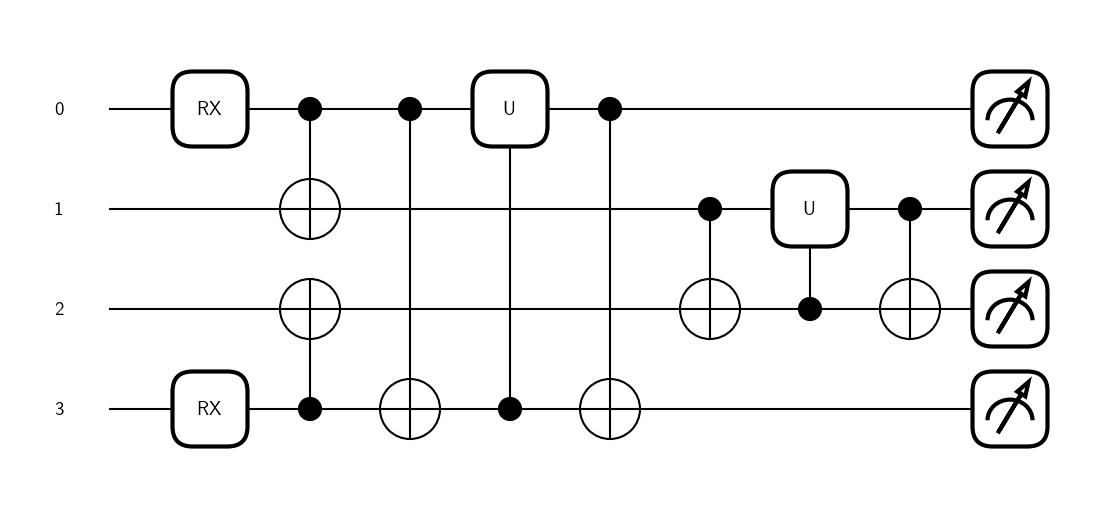

RuntimeError: latex was not able to process the following string:
b'|\\u03a8\\u27e9'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpm_y6iqkm ade9d9d8b34fcd622f96d89d95831ab2.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./ade9d9d8b34fcd622f96d89d95831ab2.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/latex/geometry/geometry.sty
(/us

<Figure size 1000x500 with 1 Axes>

In [21]:
num_qubits = 4
dev1 = qml.device("default.qubit", wires=num_qubits)

@qml.qnode(dev1)
def phi_inicial2(num_qubits,theta_A, theta_B,x):
    qml.RX(theta_A, wires=0)
    qml.RX(theta_B, wires=num_qubits-1)
    for i in range(1,int(num_qubits/2)):
      qml.CNOT(wires=[0, i])
      qml.CNOT(wires=[num_qubits-1,num_qubits-(i+1) ])
    for i in range(0,int(num_qubits/2)):
      qml.CNOT(wires=[i,num_qubits-(i+1)])
      qml.ControlledQubitUnitary(u_minus1(x[i]), control_wires=[num_qubits-(i+1)], wires=[i])
      qml.CNOT(wires=[i,num_qubits-(i+1)])
    return qml.state()


@qml.qnode(dev1)
def teste2(initial_state,num_qubits,x=0.5):
    qml.StatePrep(initial_state, wires=range(int(num_qubits)))
    for i in range(0,int(num_qubits/2)):
      qml.CNOT(wires=[i,num_qubits-(i+1)])
      qml.ControlledQubitUnitary(u_plus1(x), control_wires=[num_qubits-(i+1)], wires=[i])
      qml.CNOT(wires=[i,num_qubits-(i+1)])
    return qml.state()


qml.draw_mpl(phi_inicial2)(num_qubits,1,1,[0.5,0,5])
qml.draw_mpl(teste2)(phi_inicial2(num_qubits,1,1,[0.5,0,5]),num_qubits,0.5)

In [22]:
#otimização
import numpy as np
num_qubits = 4
dev1 = qml.device("default.qubit", wires=num_qubits)

@qml.qnode(dev1)
def term_state(num_qubits,theta_A, theta_B):
    qml.RX(theta_A, wires=0)
    qml.RX(theta_B, wires=num_qubits-1)
    for i in range(1,int(num_qubits/2)):
      qml.CNOT(wires=[0, i])
      qml.CNOT(wires=[num_qubits-1,num_qubits-(i+1) ])
    return qml.state()

@qml.qnode(dev1)
def circuito(x):
    for i in range(0,int(num_qubits/2)):
      qml.CNOT(wires=[i,num_qubits-(i+1)])
      qml.ControlledQubitUnitary(u_minus1(x[i]), control_wires=[num_qubits-(i+1)], wires=[i])
      qml.CNOT(wires=[i,num_qubits-(i+1)])
    return qml.state()




def loss1(state,rho):

    psiab=state*state.dag()
    psib=ptrace(psiab,1)

    rhoab=rho
    rhob=ptrace(rho,1)

    return (psib*rhob).tr()-(rhoab*psiab).tr()

def loss_function(params):
    """
    Função de perda a ser minimizada.
    Substitua por sua própria função de perda.
    """
    num_qubits = 4
    theta_A, theta_B,x=thetas_c(0.25,2)
    #rho_ab
    initial_state = term_state(4,theta_A, theta_B)
    rho = Qobj(np.outer(initial_state, np.conj(initial_state)),dims=cnot(num_qubits,0,1).dims)
    #psi_ab
    parametros = params # Valores de exemplo para os parâmetros
    state = Qobj(circuito(parametros),dims=[cnot(num_qubits,0,1).dims[0],[1]])
    #função
    rho_qu = ptrace(rho,[1,2]) # Estado inicial
    state_qu = ptrace(state,[1,2]) # Estado teste

    return loss1(state_qu,rho_qu)

def parameter_shift_gradient(params, j):
    """
    Calcula o gradiente da função de perda em relação ao parâmetro j
    usando a regra parameter-shift.
    """
    epsilon=0.05
    shifted_params_plus = params.copy()
    shifted_params_plus[j] += epsilon

    shifted_params_minus = params.copy()
    shifted_params_minus[j] -= epsilon

    gradient = (loss_function(shifted_params_plus) - loss_function(shifted_params_minus))/(2*epsilon)
    print(gradient,loss_function(shifted_params_plus),loss_function(shifted_params_minus))
    return gradient

def stochastic_gradient_descent(params, learning_rate, num_epochs,epsilon):
    """
    Executa o algoritmo SGD usando a regra parameter-shift para calcular gradientes.
    """
    epoch=0
    loss=0
    while ( epoch<num_epochs):#np.real(loss)>(-epsilon) and
      epoch+=1
      for j in range(len(params)):
          gradient = parameter_shift_gradient(params, j)
          params[j] -= learning_rate * gradient

      # Avalie a função de perda após cada época, se desejar
      loss = loss_function(params)
      print(f"Epoch {epoch+1}, Loss: {loss}")

    return params

# Exemplo de uso
params = np.random.rand(2)  # Inicialize os parâmetros aleatoriamente
learning_rate = 0.5
num_epochs = 100

optimized_params = stochastic_gradient_descent(params, learning_rate,num_epochs,0.1)
print(optimized_params)

0.0 0.11814541914702777 0.11814541914702777
0.0 0.11814541914702777 0.11814541914702777
Epoch 2, Loss: 0.11814541914702777
0.0 0.11814541914702777 0.11814541914702777
0.0 0.11814541914702777 0.11814541914702777
Epoch 3, Loss: 0.11814541914702777
0.0 0.11814541914702777 0.11814541914702777
0.0 0.11814541914702777 0.11814541914702777
Epoch 4, Loss: 0.11814541914702777
0.0 0.11814541914702777 0.11814541914702777
0.0 0.11814541914702777 0.11814541914702777
Epoch 5, Loss: 0.11814541914702777
0.0 0.11814541914702777 0.11814541914702777
0.0 0.11814541914702777 0.11814541914702777
Epoch 6, Loss: 0.11814541914702777
0.0 0.11814541914702777 0.11814541914702777
0.0 0.11814541914702777 0.11814541914702777
Epoch 7, Loss: 0.11814541914702777
0.0 0.11814541914702777 0.11814541914702777
0.0 0.11814541914702777 0.11814541914702777
Epoch 8, Loss: 0.11814541914702777
0.0 0.11814541914702777 0.11814541914702777
0.0 0.11814541914702777 0.11814541914702777
Epoch 9, Loss: 0.11814541914702777
0.0 0.1181454191